<a href="https://colab.research.google.com/github/24-nyalim/CarEase/blob/main/Titanic_csv.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Initial missing values:
 PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64
Variance explained by PC1: 0.23
Variance explained by PC2: 0.22


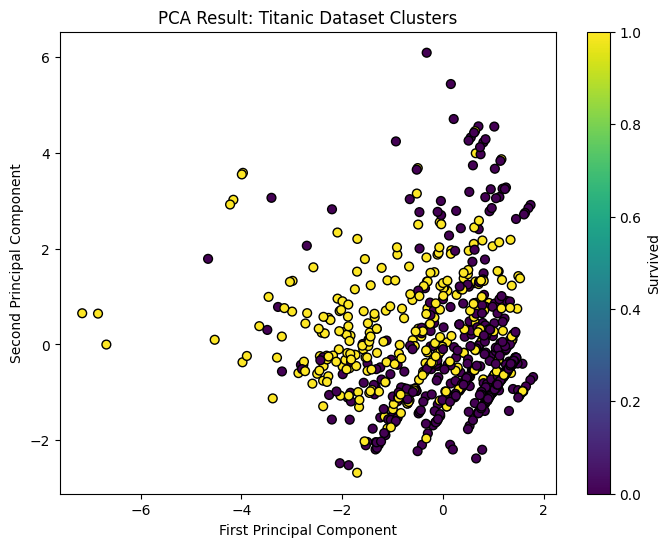

Bag of Words Feature Matrix Shape: (891, 50)
Training Complete.


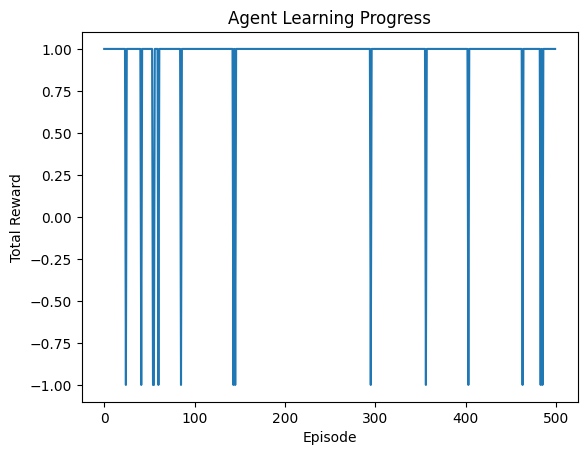

In [21]:
from google.colab import files
import pandas as pd
import io

df = pd.read_csv('Titanic-Dataset.csv')
df.head()
df.isnull().sum()
# Check for missing values
print("Initial missing values:\n", df.isnull().sum())

# Handle numerical gaps: Impute 'Age' with the median
df['Age'] = df['Age'].fillna(df['Age'].median())

# Handle categorical gaps: Impute 'Embarked' with the mode (most frequent value)
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Remove irrelevant columns or those with too many missing values
df.drop(columns=['Cabin', 'PassengerId', 'Ticket', 'Name'], inplace=True)

# Remove duplicate rows
df.drop_duplicates(inplace=True)


# --- Start of fix ---
from sklearn.preprocessing import StandardScaler

# Separate features (X) and target (y)
X = df.drop('Survived', axis=1)
y = df['Survived']

# Convert categorical features into dummy variables
X = pd.get_dummies(X, columns=['Sex', 'Embarked'], drop_first=True)

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Assign target for plotting
target = y
# --- End of fix ---

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
# Apply PCA for dimensionality reduction (reducing to 2 components for visualization)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
# Explain variance retained
explained_variance = pca.explained_variance_ratio_
print(f"Variance explained by PC1: {explained_variance[0]:.2f}")
print(f"Variance explained by PC2: {explained_variance[1]:.2f}")
# Visualize results
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=target, cmap='viridis', edgecolor='k', s=40)
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.title('PCA Result: Titanic Dataset Clusters')
plt.colorbar(label='Survived')
plt.show()
from sklearn.feature_extraction.text import CountVectorizer

# Reload names for the NLP task if they were dropped
df_raw = pd.read_csv('Titanic-Dataset.csv')
names = df_raw['Name']

# Build Bag of Words model
vectorizer = CountVectorizer(stop_words='english', max_features=50)
X_bow = vectorizer.fit_transform(names)

# Display feature matrix shape
print(f"Bag of Words Feature Matrix Shape: {X_bow.shape}")

#task 5
import numpy as np
import matplotlib.pyplot as plt

# Define the grid (4x4)
# 0 = Path, -1 = Trap, 1 = Goal
environment = np.array([
    [0,  0,  0,  1],
    [0, -1,  0, -1],
    [0,  0,  0,  0],
    [-1, 0, -1, 0]
])

# Parameters
states = 16  # 4x4 grid
actions = 4 # 0: Up, 1: Down, 2: Left, 3: Right
q_table = np.zeros((states, actions)) # Initialize Q-table with zeros

def get_next_action(state, epsilon):
    # Exploration vs Exploitation
    if np.random.uniform(0, 1) < epsilon:
        return np.random.randint(actions) # Explore: random move
    else:
        return np.argmax(q_table[state]) # Exploit: best known move

def get_reward(row, col):
    return environment[row, col]

# Training Hyperparameters
alpha = 0.1    # Learning rate
gamma = 0.9    # Discount factor (importance of future rewards)
epsilon = 0.1  # Exploration rate
episodes = 500 # How many times the agent tries the maze

rewards_history = []

for i in range(episodes):
    state = 0 # Start at top-left (0,0)
    total_reward = 0

    while state != 3: # Target is the top-right corner (index 3)
        row, col = divmod(state, 4)
        action = get_next_action(state, epsilon)

        # Calculate new position
        new_row, new_col = row, col
        if action == 0 and row > 0: new_row -= 1    # Up
        elif action == 1 and row < 3: new_row += 1  # Down
        elif action == 2 and col > 0: new_col -= 1  # Left
        elif action == 3 and col < 3: new_col += 1  # Right

        new_state = new_row * 4 + new_col
        reward = get_reward(new_row, new_col)

        # Q-Learning Formula: Update the Q-table
        old_value = q_table[state, action]
        next_max = np.max(q_table[new_state])

        q_table[state, action] = old_value + alpha * (reward + gamma * next_max - old_value)

        state = new_state
        total_reward += reward
        if reward == -1: break # Agent fell in a hole, end episode

    rewards_history.append(total_reward)

print("Training Complete.")

plt.plot(rewards_history)
plt.title('Agent Learning Progress')
plt.xlabel('Episode')
plt.ylabel('Total Reward')
plt.show()


In [ ]:
from google.colab import drive
drive.mount('/content/drive')